In [ ]:
%%writefile utils.py
import numpy as np

def generate_random_sales(min_val, max_val, size):
    """Generate random sales data between min_val and max_val"""
    return np.random.randint(min_val, max_val + 1, size=size)

Writing utils.py


In [ ]:
import os

# Create data folder if it doesn't exist
os.makedirs('data', exist_ok=True)
print("✓ 'data/' folder created")

✓ 'data/' folder created


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from utils import generate_random_sales

# Créer le dossier data
os.makedirs('data', exist_ok=True)

# Configuration
np.random.seed(42)

print("=" * 60)
print("📊 MONTHLY SALES ANALYSIS PROJECT - GOOGLE COLAB")
print("=" * 60)
print("✓ Environment ready!")

📊 MONTHLY SALES ANALYSIS PROJECT - GOOGLE COLAB
✓ Environment ready!


In [ ]:
# ============================================================================
# STEP 1: DATA GENERATION
# ============================================================================
print("\n[STEP 1] Generating Initial Data...")

# Generate monthly dates for 2025
dates = pd.date_range('2025-01-01', '2025-12-01', freq='MS')

# Generate random sales for 4 products
product_a = generate_random_sales(50, 100, 12)
product_b = generate_random_sales(30, 80, 12)
product_c = generate_random_sales(20, 60, 12)
product_d = generate_random_sales(10, 50, 12)

# Create initial DataFrame
df_initial = pd.DataFrame({
    'Date': dates,
    'Product_A': product_a,
    'Product_B': product_b,
    'Product_C': product_c,
    'Product_D': product_d
})

# Save to data folder
df_initial.to_csv('data/initial.csv', index=False)
print("✓ Saved: data/initial.csv")
print("\nInitial Data Preview:")
df_initial.head()


[STEP 1] Generating Initial Data...
✓ Saved: data/initial.csv

Initial Data Preview:


,Date,Product_A,Product_B,Product_C,Product_D
0,2025-01-01,88,65,52,18
1,2025-02-01,78,69,31,48
2,2025-03-01,64,53,41,27
3,2025-04-01,92,32,44,13
4,2025-05-01,57,51,46,34


In [ ]:
# ============================================================================
# STEP 2: BUILD DATAFRAME WITH METRICS
# ============================================================================
print("\n[STEP 2] Building DataFrame with Calculated Metrics...")

# Create working DataFrame
df = df_initial.copy()
df['Month'] = df['Date'].dt.strftime('%Y-%m')

# Define product columns
product_columns = ['Product_A', 'Product_B', 'Product_C', 'Product_D']

# Compute metrics
df['Total_Sales'] = df[product_columns].sum(axis=1)
df['Average_Sales'] = df[product_columns].mean(axis=1)
df['Month_over_Month_Growth'] = df['Total_Sales'].pct_change() * 100
df['Quarter'] = pd.PeriodIndex(df['Date'], freq='Q')
df['Max_Sales_Product'] = df[product_columns].idxmax(axis=1)
df['Min_Sales_Product'] = df[product_columns].idxmin(axis=1)

# Save final dataset
df.to_csv('data/final.csv', index=False)
print("✓ Saved: data/final.csv")
print("\nFinal Data Preview:")
df[['Month', 'Total_Sales', 'Average_Sales', 'Quarter', 'Max_Sales_Product']].head()


[STEP 2] Building DataFrame with Calculated Metrics...
✓ Saved: data/final.csv

Final Data Preview:


,Month,Total_Sales,Average_Sales,Quarter,Max_Sales_Product
0,2025-01,223,55.75,2025Q1,Product_A
1,2025-02,226,56.50,2025Q1,Product_A
2,2025-03,185,46.25,2025Q1,Product_A
3,2025-04,181,45.25,2025Q2,Product_A
4,2025-05,188,47.00,2025Q2,Product_A


In [ ]:
# ============================================================================
# STEP 3: PIVOT TABLES & SUMMARIES
# ============================================================================
print("\n[STEP 3] Creating Pivot Tables...")

# Pivot tables
pivot_avg = df.pivot_table(values=product_columns, index='Quarter', aggfunc='mean')
pivot_total = df.pivot_table(values='Total_Sales', index='Quarter', aggfunc='sum')

print("📊 Average Sales per Quarter by Product:")
pivot_avg.round(2)

print("\n📊 Total Sales per Quarter:")
pivot_total

# Save pivot tables
with open('data/output.csv', 'w') as f:
    f.write("AVERAGE SALES PER QUARTER BY PRODUCT\n")
    pivot_avg.to_csv(f)
    f.write("\n\nTOTAL SALES PER QUARTER\n")
    pivot_total.to_csv(f)

print("\n✓ Saved: data/output.csv")


[STEP 3] Creating Pivot Tables...
📊 Average Sales per Quarter by Product:

📊 Total Sales per Quarter:

✓ Saved: data/output.csv


In [ ]:
# ============================================================================
# STEP 4: KEY INSIGHTS
# ============================================================================
print("\n[STEP 4] Extracting Key Insights...")

# Best month
best_month_idx = df['Total_Sales'].idxmax()
best_month = df.loc[best_month_idx, 'Month']
best_month_sales = df.loc[best_month_idx, 'Total_Sales']

# Best product
annual_sales = df[product_columns].sum()
best_product = annual_sales.idxmax()
best_product_sales = annual_sales[best_product]

# Best quarter
quarterly_sales = df.groupby('Quarter')['Total_Sales'].sum()
best_quarter = quarterly_sales.idxmax()
best_quarter_sales = quarterly_sales[best_quarter]

print(f"\n🎯 KEY INSIGHTS:")
print(f"   🏆 Best Month: {best_month} ({best_month_sales} units)")
print(f"   🏆 Best Product: {best_product} ({best_product_sales} units/year)")
print(f"   🏆 Best Quarter: {best_quarter} ({best_quarter_sales} units)")


[STEP 4] Extracting Key Insights...

🎯 KEY INSIGHTS:
   🏆 Best Month: 2025-02 (226 units)
   🏆 Best Product: Product_A (870 units/year)
   🏆 Best Quarter: 2025Q1 (634 units)



[STEP 5] Creating Visualizations...


/tmp/ipython-input-656165611.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


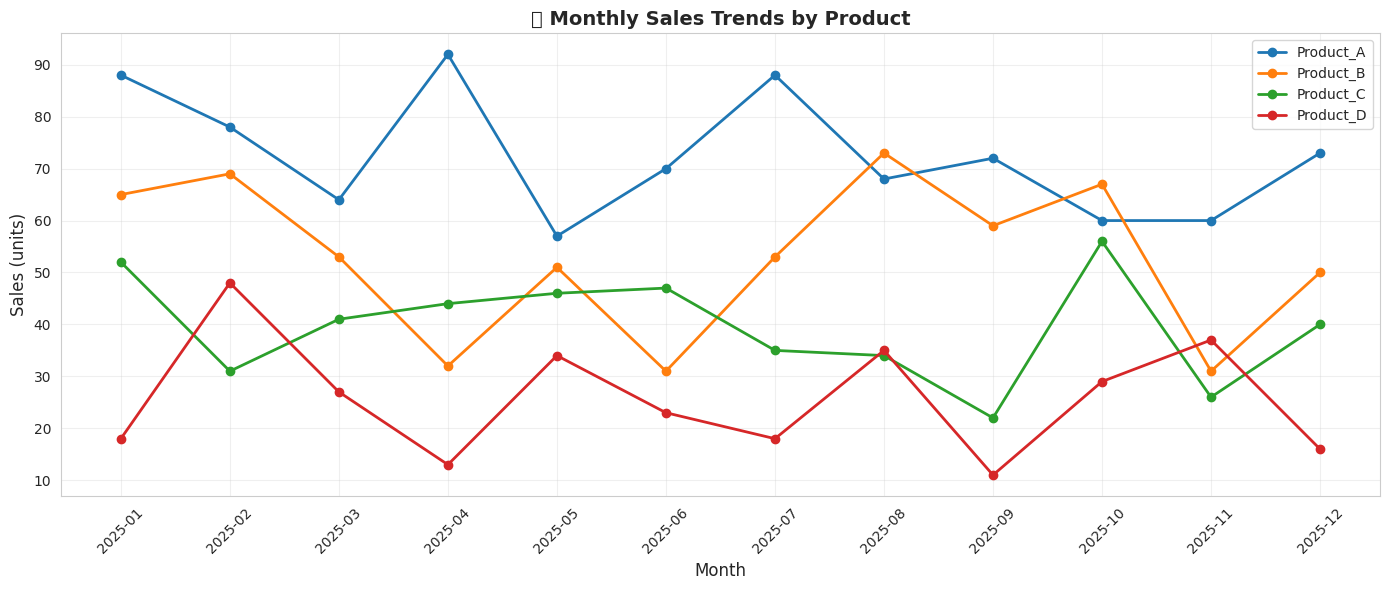

In [ ]:
# ============================================================================
# STEP 5: VISUALIZATIONS
# ============================================================================
print("\n[STEP 5] Creating Visualizations...")

# Set style
sns.set_style("whitegrid")

# Visualization 1: Line Chart
plt.figure(figsize=(14, 6))
for product in product_columns:
    plt.plot(df['Month'], df[product], marker='o', label=product, linewidth=2, markersize=6)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales (units)', fontsize=12)
plt.title('📈 Monthly Sales Trends by Product', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3827845990.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3827845990.py:18: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


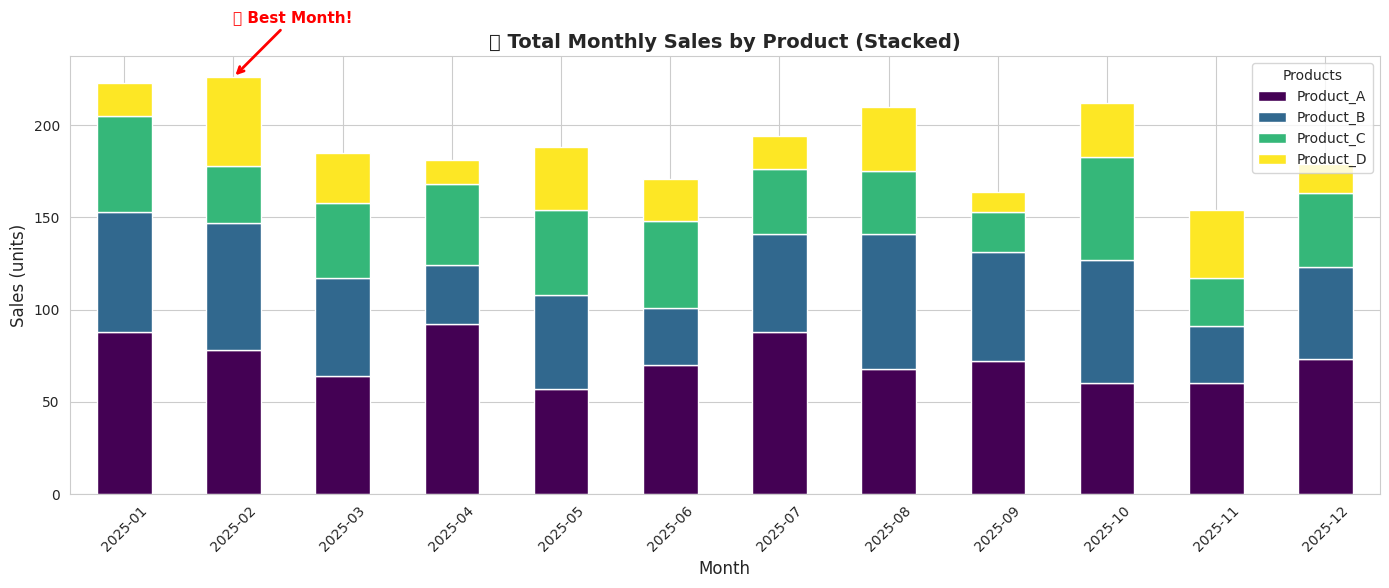

In [ ]:
# Visualization 2: Stacked Bar Chart
plt.figure(figsize=(14, 6))
df.plot(x='Month', y=product_columns, kind='bar', stacked=True,
        colormap='viridis', figsize=(14, 6))
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales (units)', fontsize=12)
plt.title('📊 Total Monthly Sales by Product (Stacked)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Products', fontsize=10)

# Annotate best month
best_month_position = df[df['Month'] == best_month].index[0]
plt.annotate('🏆 Best Month!',
             xy=(best_month_position, best_month_sales),
             xytext=(best_month_position, best_month_sales + 30),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, color='red', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2982847699.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Product', y='Sales', palette='Set2')
/tmp/ipython-input-2982847699.py:11: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


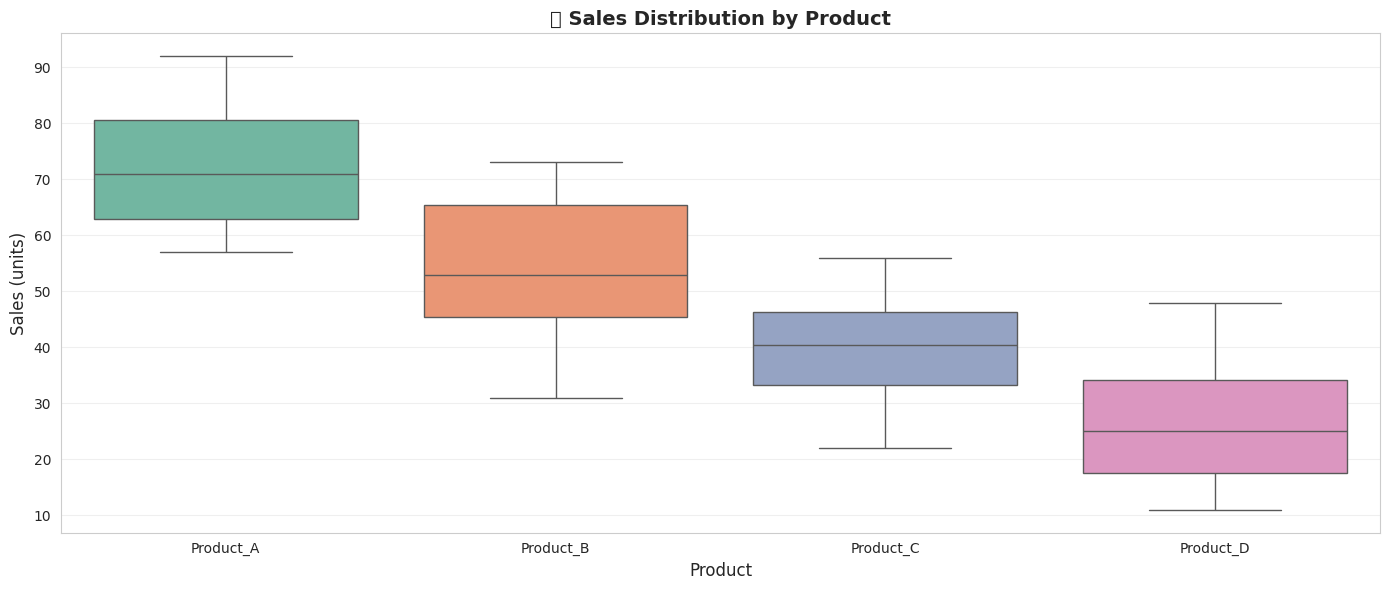

✓ All visualizations displayed!


In [ ]:
# Visualization 4: Seaborn Boxplot
plt.figure(figsize=(14, 6))
df_melted = df.melt(value_vars=product_columns,
                     var_name='Product',
                     value_name='Sales')
sns.boxplot(data=df_melted, x='Product', y='Sales', palette='Set2')
plt.xlabel('Product', fontsize=12)
plt.ylabel('Sales (units)', fontsize=12)
plt.title('📦 Sales Distribution by Product', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ All visualizations displayed!")

In [ ]:
# ============================================================================
# STEP 6: CONCLUSION QUESTIONS & ANALYSIS
# ============================================================================
print("\n" + "=" * 60)
print("📝 CONCLUSION QUESTIONS & ANALYSIS")
print("=" * 60)

print("\n1️⃣ Which product contributes the most to overall sales?")
print(f"   Answer: {best_product}")
print(f"   Total Annual Sales: {best_product_sales} units")

print("\n2️⃣ Which quarter performs best and why?")
print(f"   Answer: {best_quarter}")
print(f"   Total Sales: {best_quarter_sales} units")

print("\n3️⃣ How to improve sales strategy for next year?")
print("   📌 Recommendations:")
print(f"   • Focus marketing budget on {best_product}")
print(f"   • Prepare extra inventory for {best_quarter}")
print("   • Launch promotions during weak months")
print("   • Analyze underperforming products")

print("\n" + "=" * 60)
print("✅ PROJECT COMPLETED SUCCESSFULLY IN GOOGLE COLAB!")
print("=" * 60)


📝 CONCLUSION QUESTIONS & ANALYSIS

1️⃣ Which product contributes the most to overall sales?
   Answer: Product_A
   Total Annual Sales: 870 units

2️⃣ Which quarter performs best and why?
   Answer: 2025Q1
   Total Sales: 634 units

3️⃣ How to improve sales strategy for next year?
   📌 Recommendations:
   • Focus marketing budget on Product_A
   • Prepare extra inventory for 2025Q1
   • Launch promotions during weak months
   • Analyze underperforming products

✅ PROJECT COMPLETED SUCCESSFULLY IN GOOGLE COLAB!
